In [3]:
import pyarrow.dataset as ds
import pyarrow.compute as pc

dataset = ds.dataset(f"../../datasets/winapps.parquet", format="parquet")
print("Loading dataset...")
df_winapp_app_train = dataset.to_table(filter=(pc.match_like(pc.field("meta.sample.id"), "202407%") | pc.match_like(pc.field("meta.sample.id"), "202408%"))).to_pandas()
print(f"df_winapp_app_train={len(df_winapp_app_train)}")
df_winapp_app_val = dataset.to_table(filter=(pc.match_like(pc.field("meta.sample.id"), "202409%"))).to_pandas()
print(f"df_winapp_app_val={len(df_winapp_app_val)}")
df_winapp_app_test = dataset.to_table(filter=(pc.match_like(pc.field("meta.sample.id"), "202410%") | pc.match_like(pc.field("meta.sample.id"), "202411%"))).to_pandas()
print(f"df_winapp_app_test={len(df_winapp_app_test)}")

Loading dataset...
df_winapp_app_train=17071
df_winapp_app_val=8531
df_winapp_app_test=3924


In [9]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Iterable, Optional, Sequence, Tuple, List, Dict, Any

import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split


# ----------------------------
# Config
# ----------------------------

@dataclass(frozen=True)
class IFConfig:
    # Feature choices
    num_cols: Tuple[str, ...] = ("bs", "ps", "br", "pr", "sp", "dp", "td")
    ja_cols: Tuple[str, ...] = ("tls.ja3", "tls.ja4", "tls.ja3s", "tls.ja4s")
    use_rec_stats: bool = True

    # TLS record sequence
    rec_col: str = "tls.rec"
    rec_maxlen: int = 20  # used if you want fixed-length seq features later

    # Model
    n_estimators: int = 300
    max_samples: str | int = "auto"
    contamination: float | str = "auto"
    random_state: int = 42
    n_jobs: int = -1

    # Preprocessing
    clip_ports: bool = True
    port_max: int = 65535


# ----------------------------
# Utilities: safe extraction
# ----------------------------

def _to_float_series(df: pd.DataFrame, col: str) -> pd.Series:
    if col not in df.columns:
        return pd.Series([np.nan] * len(df), index=df.index, dtype="float64")
    return pd.to_numeric(df[col], errors="coerce")


def _hash_str_series(s: pd.Series, n_buckets: int = 2**16) -> pd.Series:
    """
    Stable-ish numeric encoding for high-cardinality strings.
    Note: Python's built-in hash is salted per process; use pandas hash for stability.
    """
    # pandas.util.hash_pandas_object gives uint64
    h = pd.util.hash_pandas_object(s.fillna(""), index=False).astype("uint64")
    return (h % np.uint64(n_buckets)).astype("int64")


def _rec_stats_from_array(x: Any) -> Dict[str, float]:
    """
    x is expected to be list/np.ndarray of signed ints.
    Return simple numeric stats. Missing/invalid -> NaNs.
    """
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return {
            "rec_len": np.nan,
            "rec_abs_sum": np.nan,
            "rec_signed_sum": np.nan,
            "rec_abs_mean": np.nan,
            "rec_abs_std": np.nan,
            "rec_pos_ratio": np.nan,
            "rec_min": np.nan,
            "rec_max": np.nan,
        }
    if not isinstance(x, (list, tuple, np.ndarray)):
        return {
            "rec_len": np.nan,
            "rec_abs_sum": np.nan,
            "rec_signed_sum": np.nan,
            "rec_abs_mean": np.nan,
            "rec_abs_std": np.nan,
            "rec_pos_ratio": np.nan,
            "rec_min": np.nan,
            "rec_max": np.nan,
        }

    arr = np.asarray(x, dtype="float64")
    if arr.size == 0:
        return {
            "rec_len": 0.0,
            "rec_abs_sum": 0.0,
            "rec_signed_sum": 0.0,
            "rec_abs_mean": 0.0,
            "rec_abs_std": 0.0,
            "rec_pos_ratio": np.nan,
            "rec_min": np.nan,
            "rec_max": np.nan,
        }

    abs_arr = np.abs(arr)
    pos_ratio = float(np.mean(arr > 0)) if arr.size else np.nan

    return {
        "rec_len": float(arr.size),
        "rec_abs_sum": float(abs_arr.sum()),
        "rec_signed_sum": float(arr.sum()),
        "rec_abs_mean": float(abs_arr.mean()),
        "rec_abs_std": float(abs_arr.std(ddof=0)),
        "rec_pos_ratio": pos_ratio,
        "rec_min": float(arr.min()),
        "rec_max": float(arr.max()),
    }


# ----------------------------
# Feature builder
# ----------------------------

def build_if_features(df: pd.DataFrame, cfg: IFConfig) -> pd.DataFrame:
    """
    Build a numeric feature matrix for Isolation Forest from the flattened schema.
    Returns a DataFrame X with only numeric columns.
    """
    X_parts: List[pd.DataFrame] = []

    # Numeric columns
    num = pd.DataFrame(index=df.index)
    for c in cfg.num_cols:
        num[c] = _to_float_series(df, c)

    if cfg.clip_ports:
        for pcol in ("sp", "dp"):
            if pcol in num.columns:
                num[pcol] = num[pcol].clip(lower=0, upper=cfg.port_max)

    # Derived ratios (robust to zeros)
    eps = 1e-9
    if {"bs", "br"}.issubset(num.columns):
        num["ratio_bs_br"] = num["bs"] / (num["br"] + eps)
    if {"ps", "pr"}.issubset(num.columns):
        num["ratio_ps_pr"] = num["ps"] / (num["pr"] + eps)
    if {"bs", "ps"}.issubset(num.columns):
        num["avg_pkt_src"] = num["bs"] / (num["ps"] + eps)
    if {"br", "pr"}.issubset(num.columns):
        num["avg_pkt_dst"] = num["br"] / (num["pr"] + eps)

    X_parts.append(num)

    # Hashed encodings for TLS fingerprints
    for c in cfg.ja_cols:
        if c in df.columns:
            s = df[c].astype("string")
            enc = _hash_str_series(s, n_buckets=2**16).astype("float64")
        else:
            enc = pd.Series([np.nan] * len(df), index=df.index, dtype="float64")
        X_parts.append(pd.DataFrame({f"hash_{c}": enc}, index=df.index))

    # TLS record stats
    if cfg.use_rec_stats and cfg.rec_col in df.columns:
        rec_stats = df[cfg.rec_col].apply(_rec_stats_from_array)
        rec_stats_df = pd.DataFrame(list(rec_stats), index=df.index)
        X_parts.append(rec_stats_df)

    X = pd.concat(X_parts, axis=1)

    # Basic cleaning: replace inf, keep NaNs (IF in sklearn cannot handle NaNs -> impute)
    X = X.replace([np.inf, -np.inf], np.nan)

    # Simple imputation: median per column
    med = X.median(numeric_only=True)
    X = X.fillna(med)

    # Optional scaling: IF doesn't require it, but can help with mixed magnitudes
    # Here: log1p for heavy-tailed counters
    for c in ("bs", "br", "ps", "pr", "td", "rec_abs_sum"):
        if c in X.columns:
            X[c] = np.log1p(X[c].astype("float64"))

    return X


# ----------------------------
# Model wrapper
# ----------------------------

class IsolationForestBaseline:
    def __init__(self, cfg: IFConfig):
        self.cfg = cfg
        self.model: Optional[IsolationForest] = None
        self.feature_cols: Optional[List[str]] = None

    def fit(self, df_train: pd.DataFrame) -> "IsolationForestBaseline":
        X = build_if_features(df_train, self.cfg)
        self.feature_cols = list(X.columns)

        self.model = IsolationForest(
            n_estimators=self.cfg.n_estimators,
            max_samples=self.cfg.max_samples,
            contamination=self.cfg.contamination,
            random_state=self.cfg.random_state,
            n_jobs=self.cfg.n_jobs,
        )
        self.model.fit(X.values)
        return self

    def score(self, df: pd.DataFrame) -> np.ndarray:
        """
        Returns anomaly score where higher means 'more anomalous'.
        sklearn's score_samples: higher means 'more normal', so we negate it.
        """
        if self.model is None or self.feature_cols is None:
            raise RuntimeError("Model not fitted. Call fit() first.")

        X = build_if_features(df, self.cfg)[self.feature_cols]
        normal_score = self.model.score_samples(X.values)  # higher = more normal
        return -normal_score  # higher = more anomalous

    def predict(self, df: pd.DataFrame, threshold: float) -> np.ndarray:
        """
        threshold is applied on anomaly score from score().
        Returns 1 for anomaly, 0 for normal.
        """
        s = self.score(df)
        return (s >= threshold).astype("int8")


# ----------------------------
# Example usage
# ----------------------------

def example_pipeline(
    df_train: pd.DataFrame,
    df_val: pd.DataFrame,
    df_test: pd.DataFrame,
    target_fpr: float,
) -> Dict[str, Any]:
    """
    Train IF on df_train (benign),
    calibrate threshold on df_val (benign),
    evaluate on df_test.
    """
    cfg = IFConfig()

    clf = IsolationForestBaseline(cfg).fit(df_train)

    # --- calibration on benign validation ---
    val_scores = clf.score(df_val)
    threshold = float(np.quantile(val_scores, 1.0 - target_fpr))

    # --- evaluation ---
    test_scores = clf.score(df_test)
    test_pred = (test_scores >= threshold)

    return {
        "target_fpr": target_fpr,
        "threshold": threshold,
        "val_fpr": float(np.mean(val_scores >= threshold)),
        "test_anom_rate": float(np.mean(test_pred)),
        "test_scores": test_scores,   # optional, can be dropped
    }

def run_fpr_sweep(
    df_train: pd.DataFrame,
    df_val: pd.DataFrame,
    df_test: pd.DataFrame,
    fpr_list: Iterable[float],
) -> pd.DataFrame:
    """
    Run the pipeline for multiple FPR targets and
    return a compact summary table.
    """
    rows = []

    for fpr in fpr_list:
        res = example_pipeline(
            df_train=df_train,
            df_val=df_val,
            df_test=df_test,
            target_fpr=fpr,
        )

        rows.append({
            "target_fpr": res["target_fpr"],
            "threshold": res["threshold"],
            "val_fpr_realized": res["val_fpr"],
            "test_anom_rate": res["test_anom_rate"],
        })

    return pd.DataFrame(rows).sort_values("target_fpr")
  

## Anomaly Rate vs Target FPR (Main Operating Curve)

The anomaly rate vs target false positive rate curve illustrates the sensitivity–noise trade-off of the detector under calibrated operating points. Each point corresponds to a threshold chosen to achieve a fixed false positive rate on benign validation traffic. 


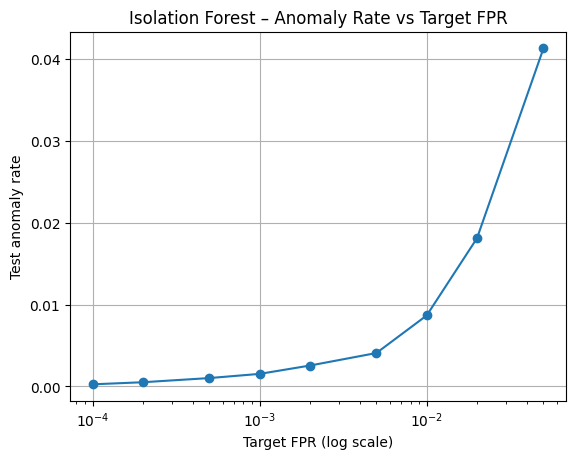

In [11]:
fpr_values = [
    1e-4,
    2e-4,
    5e-4,
    1e-3,
    5e-3,
    2e-3,
    1e-2,
    2e-2,
    5e-2,
]

df_results = run_fpr_sweep(
    df_train=df_winapp_app_train,
    df_val=df_winapp_app_val,
    df_test=df_winapp_app_test,
    fpr_list=fpr_values,
)

import matplotlib.pyplot as plt

plt.figure()
plt.plot(
    df_results["target_fpr"],
    df_results["test_anom_rate"],
    marker="o",
)
plt.xscale("log")
plt.xlabel("Target FPR (log scale)")
plt.ylabel("Test anomaly rate")
plt.title("Isolation Forest – Anomaly Rate vs Target FPR")
plt.grid(True)
plt.show()